## 1. Предобработка
Выполняем все те же операции, что и в бейслайне

In [49]:
# Необходимо для корректной работы внешних .py файлов
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [126]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OrdinalEncoder, OneHotEncoder
from sklearn.model_selection import KFold
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from sklearn.base import clone
from helper import *
from plots import *
import random

In [117]:
# фиксируем состояние генератора псевдослучайных чисел. Это необходимо, чтобы результаты модели не менялись с каждым новым запуском 
SEED = 42 # можно указать любое число
np.random.seed(SEED)
random.seed(SEED)

## 1. Предобработка

In [118]:
# фиксируем состояние генератора псевдослучайных чисел. Это необходимо, чтобы результаты модели не менялись с каждым новым запуском 
SEED = 42 # можно указать любое число
np.random.seed(SEED)
random.seed(SEED)

# Загружаем датасет в память
df = pd.read_csv("diamonds.csv", index_col=0)
df_preprocessed = df.copy()
# Дубликаты
df_preprocessed.drop_duplicates(inplace=True)
# Удаление строк, где x/y/z = 0
df_preprocessed = df_preprocessed[(df_preprocessed[["x", "y", "z"]] != 0).all(axis=1)]
# делим данные на признаки и таргет
X, y = divide_data(df_preprocessed, "price")

categorical_cols = ["cut", "color", "clarity"]
category_orders = [
    ["Fair", "Good", "Very Good", "Premium", "Ideal"], # cut
    ["D", "E", "F", "G", "H", "I", "J"], # color
    ["IF", "VVS1", "VVS2", "VS1", "VS2", "SI1", "SI2", "I1"], # clarity
]

preprocessor = Pipeline([    
    ("transformations", ColumnTransformer(
        [("encoder", OrdinalEncoder(categories=category_orders), categorical_cols)],
        remainder="passthrough",  # числовые колонки передаются без изменений
        verbose_feature_names_out=False
    ))
])

preprocessor.set_output(transform="pandas")

,steps,"[('transformations', ...)]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('encoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{transformer_name}""``. See :meth:`str.format` method from the standard library for more info... versionadded:: 1.0.. versionchanged:: 1.6 `verbose_feature_names_out` can be a callable or a string to be formatted.",False
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_

In [119]:
# сохраним все бейслайн модели в виде списка для удобства
models = [
    ('DecisionTreeRegressor', DecisionTreeRegressor(random_state=SEED, max_depth=14)),
    ('RandomForestRegressor', RandomForestRegressor(random_state=SEED)),
    ('LGBMRegressor', LGBMRegressor(random_state=SEED))
]

In [ ]:
# используем 5-блочную кросс-валидацию
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000254 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1273
[LightGBM] [Info] Number of data points in the train set: 43020, number of used features: 9
[LightGBM] [Info] Start training from score 3930.301790
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000868 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1276
[LightGBM] [Info] Number of data points in the train set: 43020, number of used features: 9
[LightGBM] [Info] Start training from score 3937.058415
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000254 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Tota

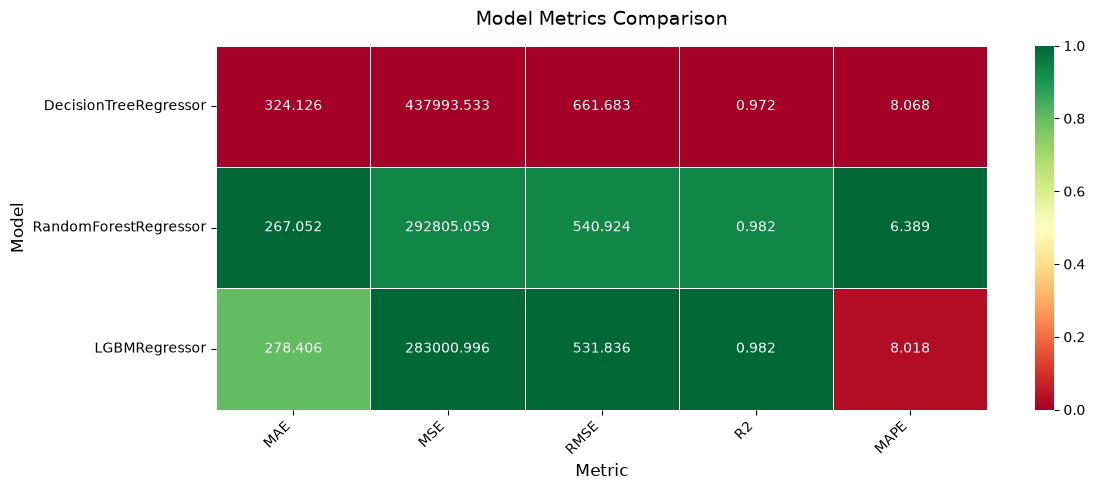

In [121]:
initial_metrics = train_evaluate_models_cv(
    models=models,
    X=X,
    y=y,
    preprocessor=preprocessor,
    cv=cv,
    seed=SEED
)

## 2. Преобразования данных и feature engineering

### 2.1 Логарифмическое преобразование

#### 2.1.1 Без удаления столбцов

In [56]:
X_log = X.copy()

In [57]:
X_log['CaratLog'] = np.log1p(X_log['carat'])

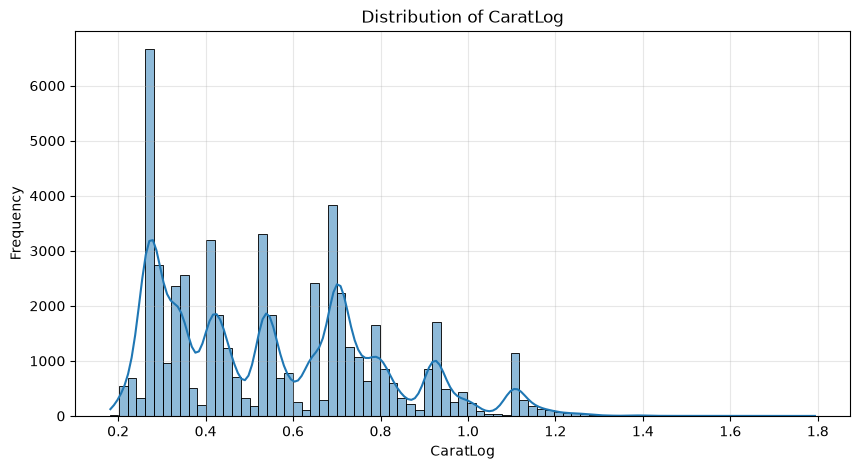

In [58]:
plot_hist_numeric(X_log, 'CaratLog')

In [59]:
preprocessor_log = clone(preprocessor)

c:\Users\meris\Desktop\Поиск работы\Обучение\Задания\regression-task\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\meris\Desktop\Поиск работы\Обучение\Задания\regression-task\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\meris\Desktop\Поиск работы\Обучение\Задания\regression-task\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000879 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1513
[LightGBM] [Info] Number of data points in the train set: 43020, number of used features: 10
[LightGBM] [Info] Start training from score 3931.021548
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000297 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1511
[LightGBM] [Info] Number of data points in the train set: 43020, number of used features: 10
[LightGBM] [Info] Start training from score 3931.795467
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000282 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] To

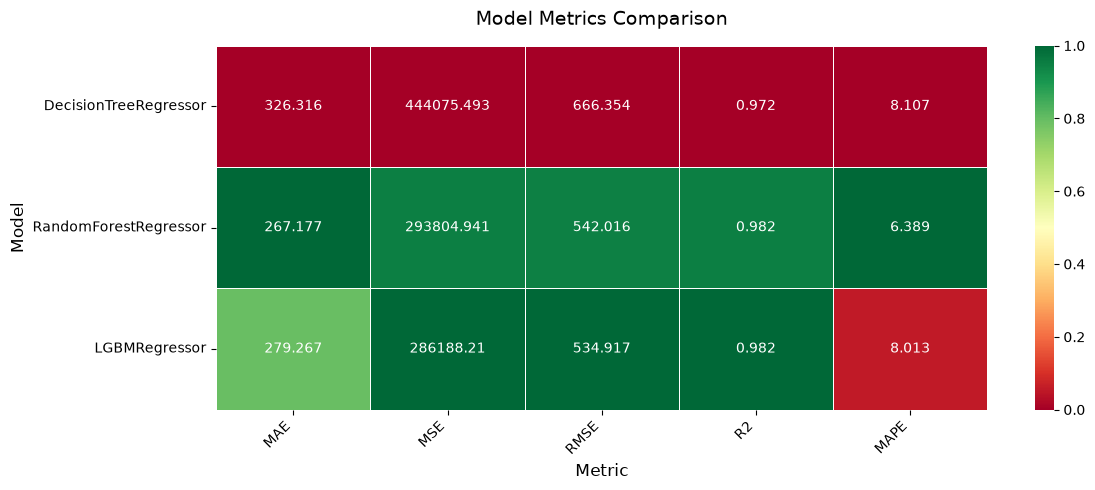

In [60]:
log_metrics = train_evaluate_models_cv(
    models=models,
    X=X_log,
    y=y,
    preprocessor=preprocessor_log,
    cv=cv,
    seed=SEED
)

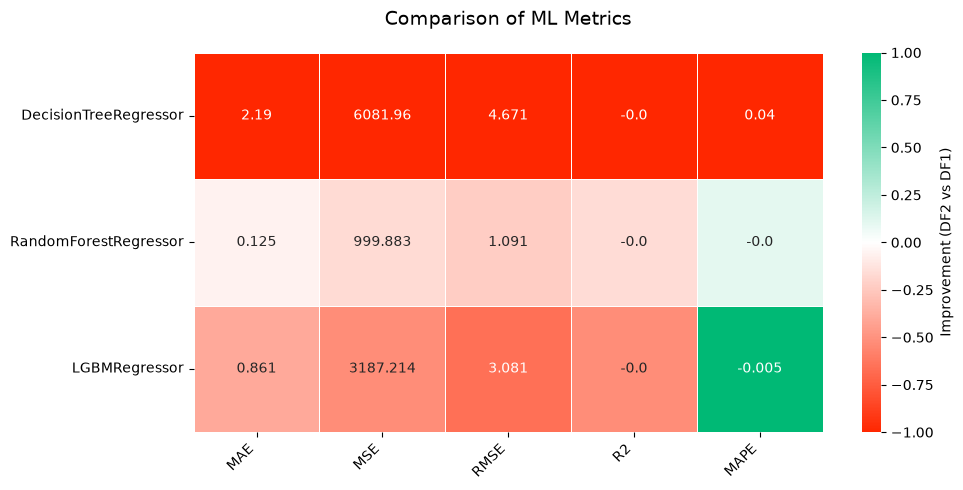

(<Figure size 1000x500 with 2 Axes>,
                             MAE          MSE      RMSE        R2      MAPE
 DecisionTreeRegressor  2.190344  6081.959659  4.671322 -0.000377  0.039622
 RandomForestRegressor  0.125150   999.882883  1.091318 -0.000061 -0.000492
 LGBMRegressor          0.861314  3187.214352  3.080603 -0.000198 -0.004841)

In [122]:
# сравним изначальные метрики с метриками после логарифмирования и выведем график
compare_metrics_heatmap(initial_metrics, log_metrics)

Положительного влияния на метрики нет

#### 2.1.2 С удалением исходных столбцов

In [62]:
X_log_delete = X.copy()

In [63]:
X_log['carat'] = np.log1p(X_log['carat'])

c:\Users\meris\Desktop\Поиск работы\Обучение\Задания\regression-task\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\meris\Desktop\Поиск работы\Обучение\Задания\regression-task\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\meris\Desktop\Поиск работы\Обучение\Задания\regression-task\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000258 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1276
[LightGBM] [Info] Number of data points in the train set: 43020, number of used features: 9
[LightGBM] [Info] Start training from score 3931.021548
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000260 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 43020, number of used features: 9
[LightGBM] [Info] Start training from score 3931.795467
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000264 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not e

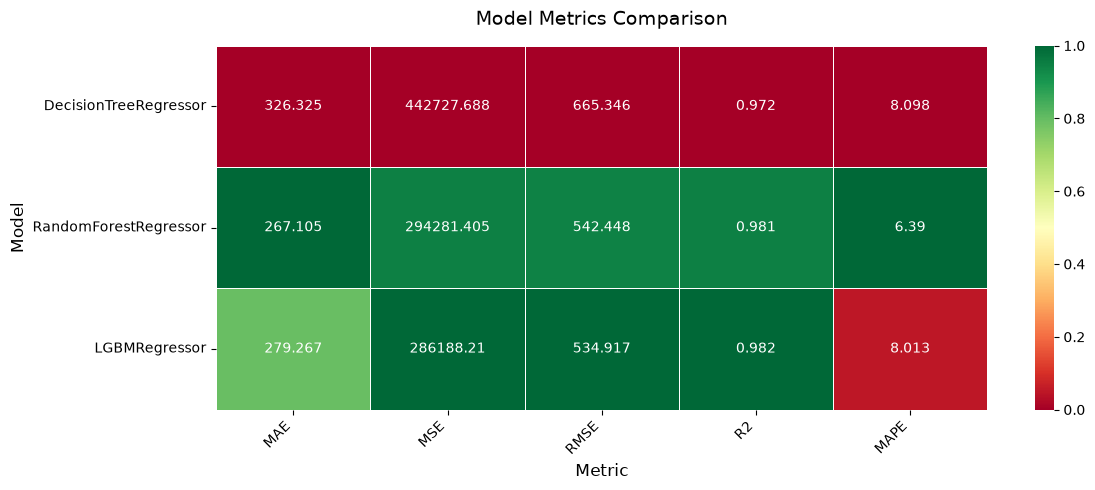

In [64]:
log_delete_metrics = train_evaluate_models_cv(
    models=models,
    X=X_log_delete,
    y=y,
    preprocessor=preprocessor,
    cv=cv,
    seed=SEED
)

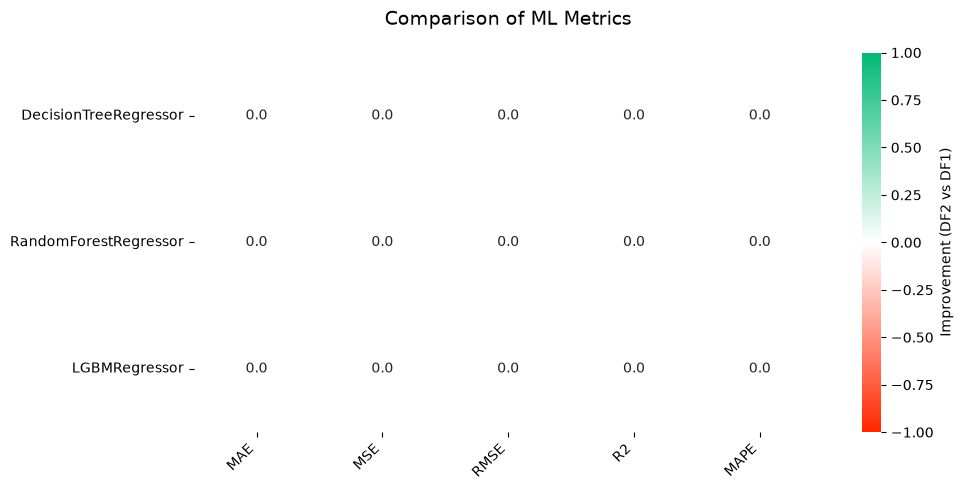

(<Figure size 1000x500 with 2 Axes>,
                        MAE  MSE  RMSE   R2  MAPE
 DecisionTreeRegressor  0.0  0.0   0.0  0.0   0.0
 RandomForestRegressor  0.0  0.0   0.0  0.0   0.0
 LGBMRegressor          0.0  0.0   0.0  0.0   0.0)

In [65]:
compare_metrics_heatmap(initial_metrics, log_delete_metrics)

Ничего не поменялось

### 2.2 volume

In [ ]:
X_volume = X.copy()
X_volume['volume'] = X_volume['x'] * X_volume['y'] * X_volume['z']

c:\Users\meris\Desktop\Поиск работы\Обучение\Задания\regression-task\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\meris\Desktop\Поиск работы\Обучение\Задания\regression-task\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\meris\Desktop\Поиск работы\Обучение\Задания\regression-task\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000270 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1531
[LightGBM] [Info] Number of data points in the train set: 43020, number of used features: 10
[LightGBM] [Info] Start training from score 3931.021548
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000277 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 43020, number of used features: 10
[LightGBM] [Info] Start training from score 3931.795467
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000253 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not

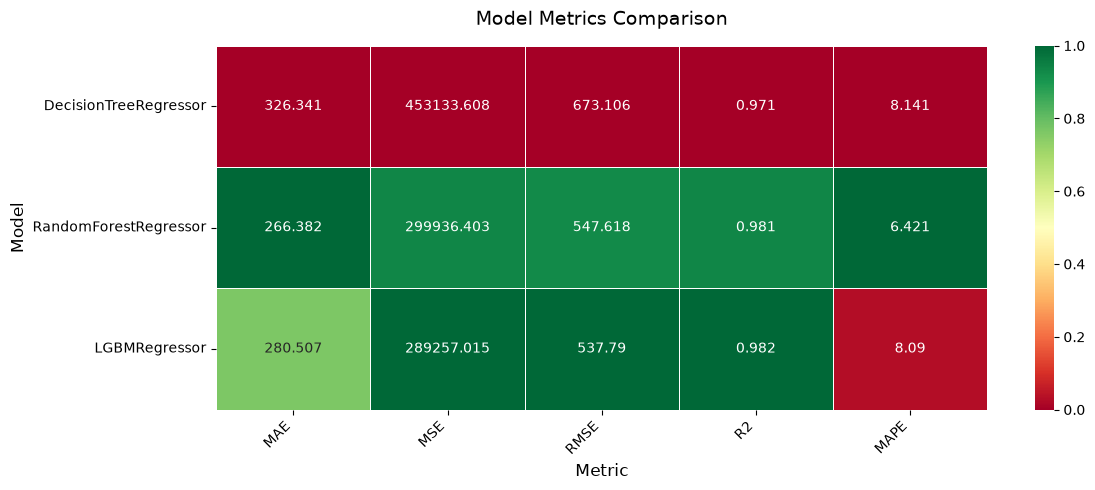

In [69]:
volume_metrics = train_evaluate_models_cv(
    models=models,
    X=X_volume,
    y=y,
    preprocessor=preprocessor,
    cv=cv,
    seed=SEED
)

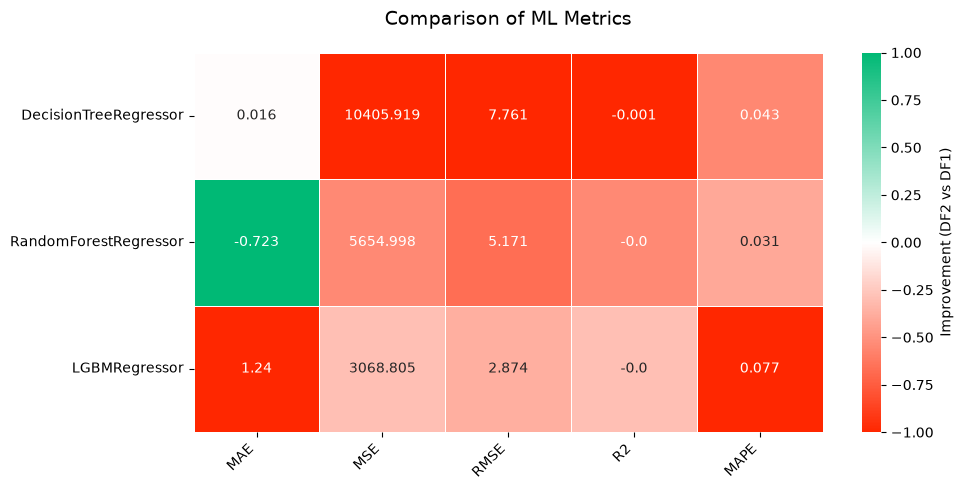

(<Figure size 1000x500 with 2 Axes>,
                             MAE           MSE      RMSE        R2      MAPE
 DecisionTreeRegressor  0.016447  10405.919497  7.760573 -0.000655  0.042896
 RandomForestRegressor -0.722848   5654.998420  5.170550 -0.000356  0.030835
 LGBMRegressor          1.239638   3068.804742  2.873599 -0.000193  0.077335)

In [70]:
compare_metrics_heatmap(initial_metrics, volume_metrics)

В основном наблюдаются ухудшения метрик

### 2.3 avg_size

c:\Users\meris\Desktop\Поиск работы\Обучение\Задания\regression-task\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\meris\Desktop\Поиск работы\Обучение\Задания\regression-task\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\meris\Desktop\Поиск работы\Обучение\Задания\regression-task\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001018 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1531
[LightGBM] [Info] Number of data points in the train set: 43020, number of used features: 10
[LightGBM] [Info] Start training from score 3931.021548
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000299 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 43020, number of used features: 10
[LightGBM] [Info] Start training from score 3931.795467
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001023 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the tra

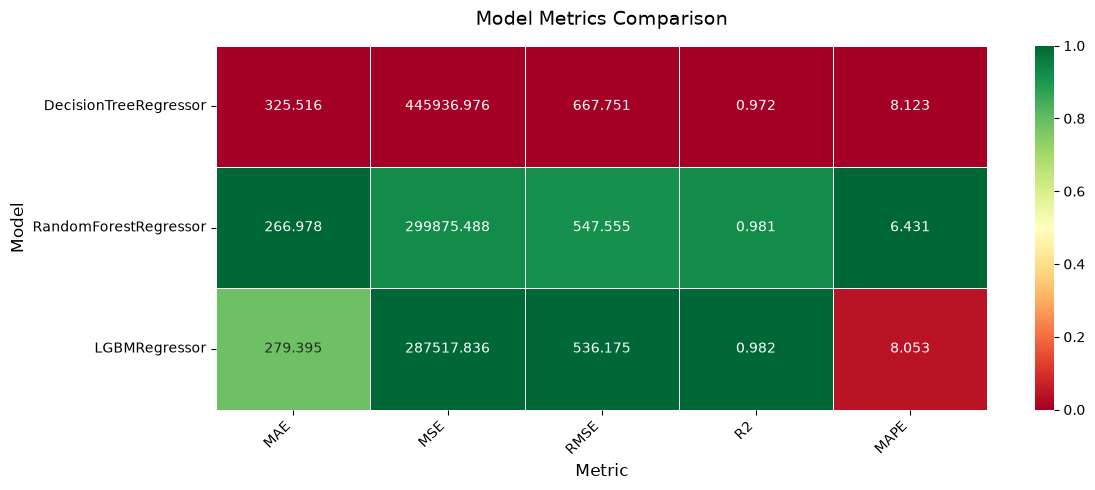

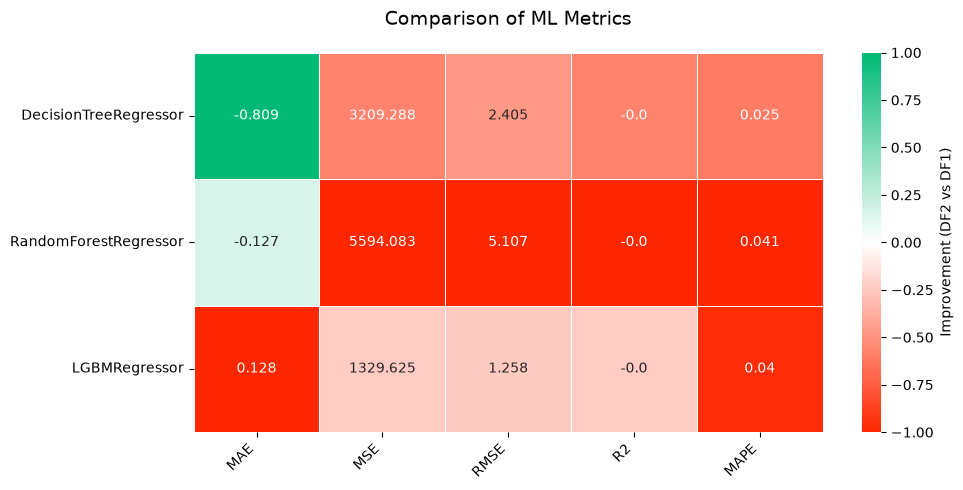

(<Figure size 1000x500 with 2 Axes>,
                             MAE          MSE      RMSE        R2      MAPE
 DecisionTreeRegressor -0.809207  3209.287556  2.405073 -0.000202  0.024824
 RandomForestRegressor -0.126693  5594.082769  5.107029 -0.000352  0.040789
 LGBMRegressor          0.127785  1329.625096  1.258139 -0.000084  0.039702)

In [71]:
X_avg_size = X.copy()
X_avg_size['avg_size'] = (X_avg_size['x'] + X_avg_size['y'] + X_avg_size['z']) / 3
avg_size_metrics = train_evaluate_models_cv(
    models=models,
    X=X_avg_size,
    y=y,
    preprocessor=preprocessor,
    cv=cv,
    seed=SEED
)
compare_metrics_heatmap(initial_metrics, avg_size_metrics)

Небольшие ухудшения метрик

### 2.4 xy_ratio

c:\Users\meris\Desktop\Поиск работы\Обучение\Задания\regression-task\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\meris\Desktop\Поиск работы\Обучение\Задания\regression-task\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\meris\Desktop\Поиск работы\Обучение\Задания\regression-task\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000546 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1531
[LightGBM] [Info] Number of data points in the train set: 43020, number of used features: 10
[LightGBM] [Info] Start training from score 3931.021548
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000944 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 43020, number of used features: 10
[LightGBM] [Info] Start training from score 3931.795467
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000258 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] To

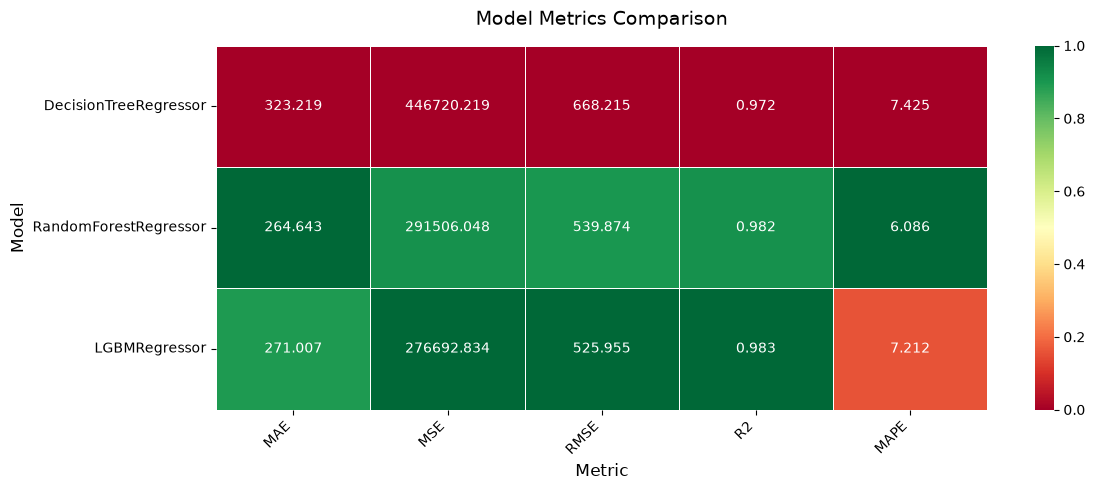

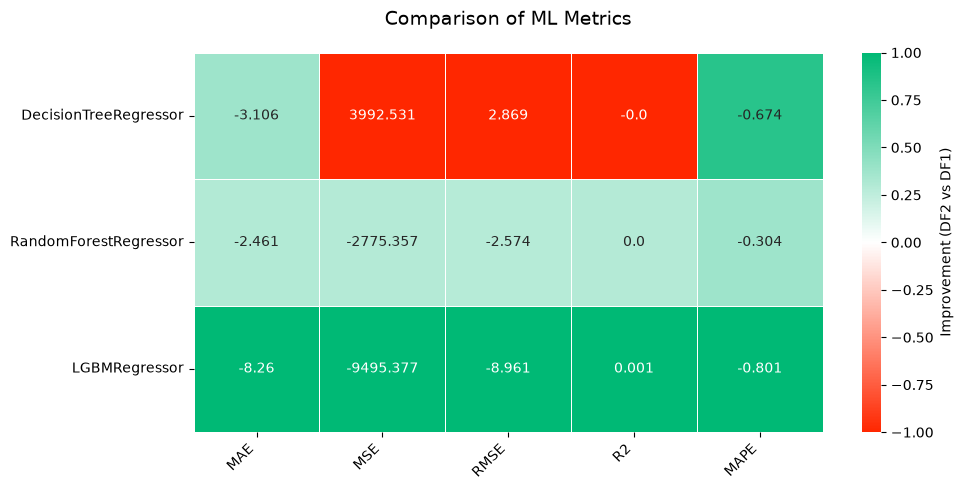

(<Figure size 1000x500 with 2 Axes>,
                             MAE          MSE      RMSE        R2      MAPE
 DecisionTreeRegressor -3.105976  3992.530516  2.869082 -0.000251 -0.673681
 RandomForestRegressor -2.461496 -2775.357266 -2.573908  0.000175 -0.303781
 LGBMRegressor         -8.260009 -9495.376551 -8.961234  0.000598 -0.801373)

In [72]:
X_xy_ratio = X.copy()
X_xy_ratio['xy_ratio'] = X_xy_ratio['x'] / (X_xy_ratio['y'] + 1e-6)
xy_ratio_metrics = train_evaluate_models_cv(
    models=models,
    X=X_xy_ratio,
    y=y,
    preprocessor=preprocessor,
    cv=cv,
    seed=SEED
)
compare_metrics_heatmap(initial_metrics, xy_ratio_metrics)

Небольшие улучшения метрик для случайного леса и бустинга

### 2.5 Применение StandardScaler (стандартизация)

#### 2.5.1 Без удаления

In [73]:
X_standard_scaler = X.copy()

In [74]:
scaled_columns = ['carat-scaled', 'x-scaled', 'y-scaled', 'z-scaled', 'table-scaled', 'depth-scaled']
X_standard_scaler[scaled_columns] = X_standard_scaler[['carat', 'x', 'y', 'z', 'table', 'depth']]

In [75]:
preprocessor_standard_scaler = clone(preprocessor)

preprocessor_standard_scaler['transformations'].transformers.append(
    ('scaler', StandardScaler(), scaled_columns)
)

c:\Users\meris\Desktop\Поиск работы\Обучение\Задания\regression-task\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\meris\Desktop\Поиск работы\Обучение\Задания\regression-task\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\meris\Desktop\Поиск работы\Обучение\Задания\regression-task\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001414 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2536
[LightGBM] [Info] Number of data points in the train set: 43020, number of used features: 15
[LightGBM] [Info] Start training from score 3931.021548
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000295 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2534
[LightGBM] [Info] Number of data points in the train set: 43020, number of used features: 15
[LightGBM] [Info] Start training from score 3931.795467
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000294 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] To

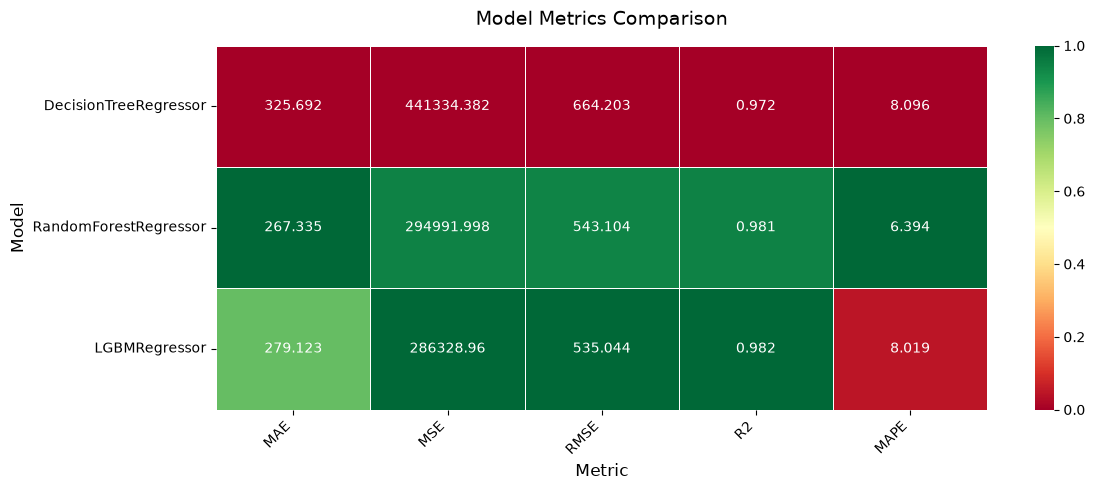

In [76]:
standard_scaler_metrics = train_evaluate_models_cv(
    models=models,
    X=X_standard_scaler,
    y=y,
    preprocessor=preprocessor_standard_scaler,
    cv=cv,
    seed=SEED
)

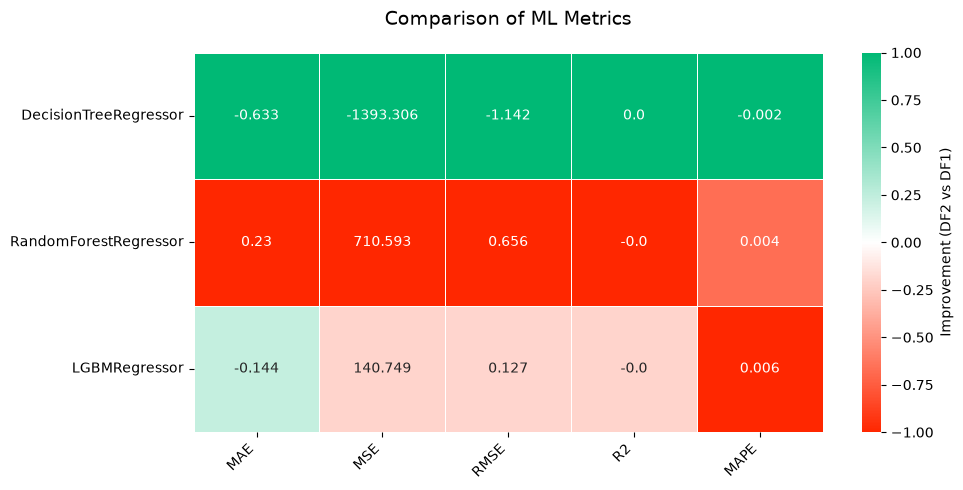

(<Figure size 1000x500 with 2 Axes>,
                             MAE          MSE      RMSE        R2      MAPE
 DecisionTreeRegressor -0.632990 -1393.306164 -1.142367  0.000088 -0.001978
 RandomForestRegressor  0.230182   710.592647  0.656378 -0.000045  0.003950
 LGBMRegressor         -0.144148   140.749120  0.126999 -0.000009  0.005890)

In [77]:
compare_metrics_heatmap(initial_metrics, standard_scaler_metrics)

Незначительное улучшение для решающего дерева, но для бустинга и леса ухудшения метрик

#### 2.5.2 С удалением

In [78]:
X_standard_scaler_del = X.copy()

In [80]:
preprocessor_standard_scaler_del = clone(preprocessor)

preprocessor_standard_scaler_del['transformations'].transformers.append(
    ('scaler', StandardScaler(), ['carat', 'x', 'y', 'z', 'table', 'depth'])
)

c:\Users\meris\Desktop\Поиск работы\Обучение\Задания\regression-task\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\meris\Desktop\Поиск работы\Обучение\Задания\regression-task\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\meris\Desktop\Поиск работы\Обучение\Задания\regression-task\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000188 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1280
[LightGBM] [Info] Number of data points in the train set: 43020, number of used features: 9
[LightGBM] [Info] Start training from score 3931.021548
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000279 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1279
[LightGBM] [Info] Number of data points in the train set: 43020, number of used features: 9
[LightGBM] [Info] Start training from score 3931.795467
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000259 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not e

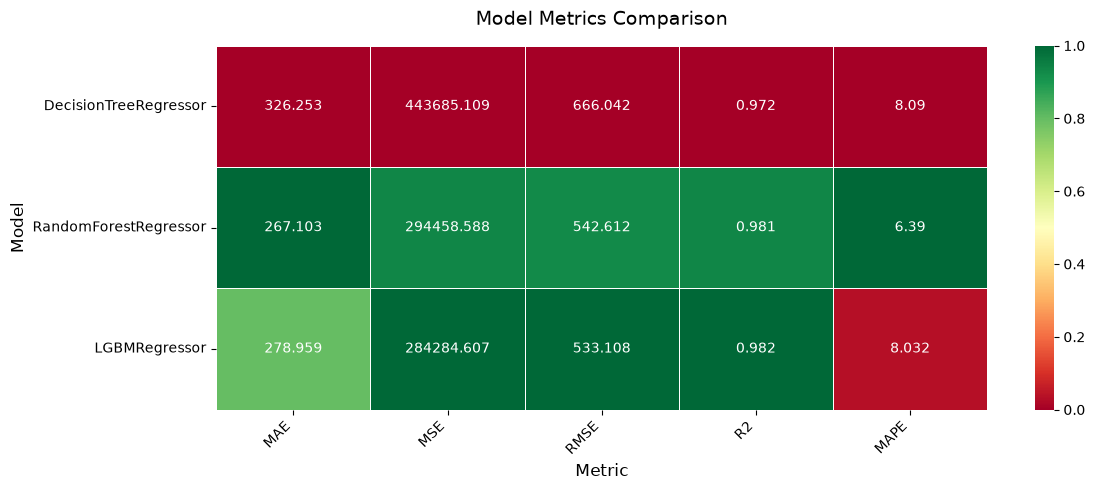

In [81]:
standard_scaler_metrics_del = train_evaluate_models_cv(
    models=models,
    X=X_standard_scaler_del,
    y=y,
    preprocessor=preprocessor_standard_scaler_del,
    cv=cv,
    seed=SEED
)

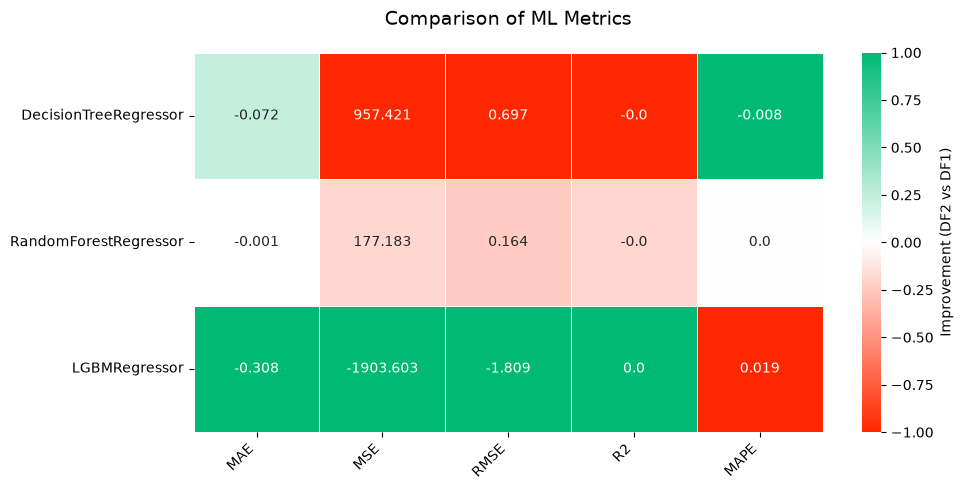

(<Figure size 1000x500 with 2 Axes>,
                             MAE          MSE      RMSE        R2      MAPE
 DecisionTreeRegressor -0.071898   957.420827  0.696726 -0.000060 -0.007983
 RandomForestRegressor -0.001101   177.182831  0.163954 -0.000011  0.000085
 LGBMRegressor         -0.308250 -1903.603463 -1.809095  0.000120  0.018584)

In [84]:
compare_metrics_heatmap(initial_metrics, standard_scaler_metrics_del)

Незначительные улучшения для бустинга

### 2.6 Нормализация

#### 2.6.1 Без удаления

In [85]:
X_normalised = X.copy()

In [86]:
scaled_columns = ['carat-scaled', 'x-scaled', 'y-scaled', 'z-scaled', 'table-scaled', 'depth-scaled']
X_normalised[scaled_columns] = X_normalised[['carat', 'x', 'y', 'z', 'table', 'depth']]

In [87]:
preprocessor_normalisation = clone(preprocessor)

preprocessor_normalisation['transformations'].transformers.append(
    ('scaler', MinMaxScaler(), scaled_columns)
)

c:\Users\meris\Desktop\Поиск работы\Обучение\Задания\regression-task\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\meris\Desktop\Поиск работы\Обучение\Задания\regression-task\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\meris\Desktop\Поиск работы\Обучение\Задания\regression-task\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001630 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2530
[LightGBM] [Info] Number of data points in the train set: 43020, number of used features: 15
[LightGBM] [Info] Start training from score 3931.021548
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001364 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2529
[LightGBM] [Info] Number of data points in the train set: 43020, number of used features: 15
[LightGBM] [Info] Start training from score 3931.795467
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001431 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2529
[LightGBM] [Info] Number of data points in the train set: 43020, number of used features: 15
[LightGBM] [Info] Sta

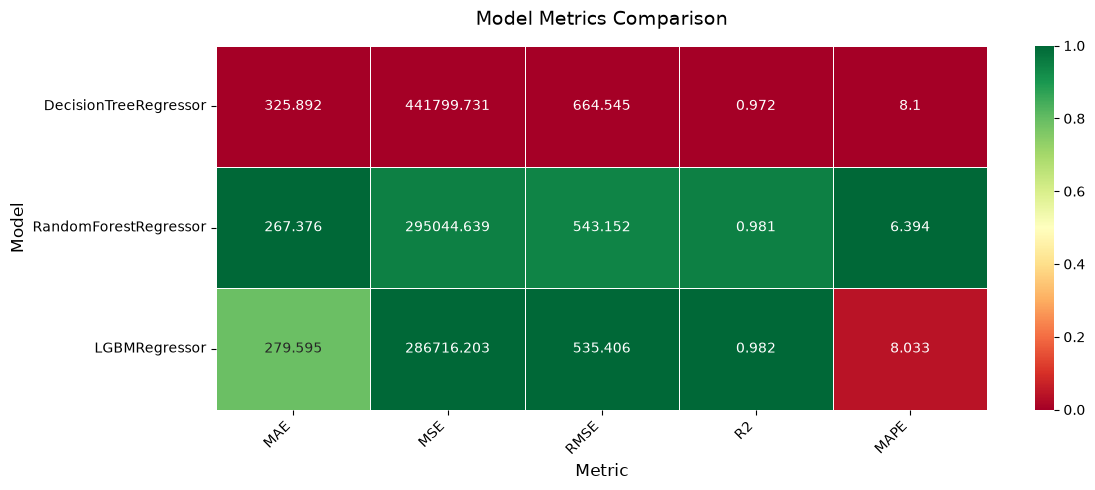

In [88]:
normalised_metrics = train_evaluate_models_cv(
    models=models,
    X=X_normalised,
    y=y,
    preprocessor=preprocessor_normalisation,
    cv=cv,
    seed=SEED
)

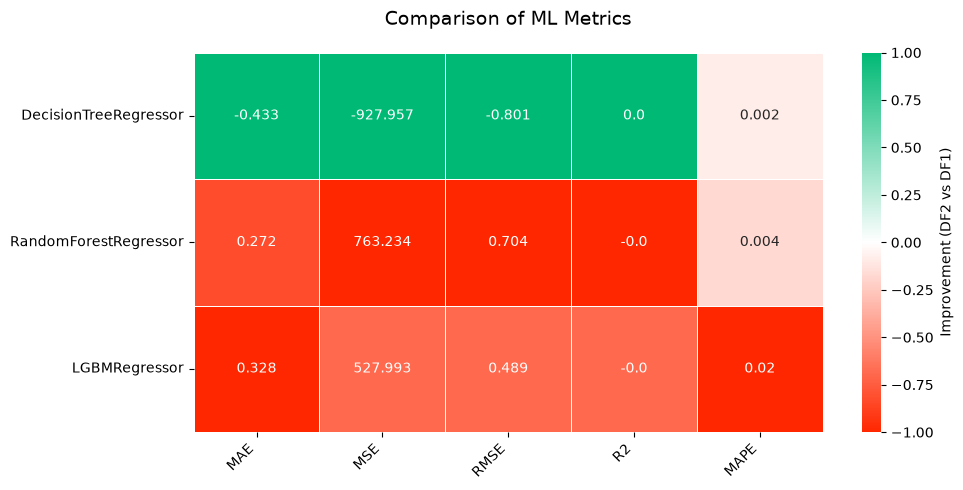

(<Figure size 1000x500 with 2 Axes>,
                             MAE         MSE      RMSE        R2      MAPE
 DecisionTreeRegressor -0.432707 -927.956973 -0.800956  0.000058  0.001609
 RandomForestRegressor  0.271661  763.233880  0.703802 -0.000048  0.003505
 LGBMRegressor          0.328150  527.992722  0.489136 -0.000033  0.019768)

In [89]:
compare_metrics_heatmap(initial_metrics, normalised_metrics)

В основном ухудшения метрик для бустинга и леса

#### 2.6.2 С удалением

In [90]:
X_normalised_del = X.copy()

In [91]:
preprocessor_normalisation_del = clone(preprocessor)

preprocessor_normalisation_del['transformations'].transformers.append(
    ('scaler', MinMaxScaler(), ['carat', 'x', 'y', 'z', 'table', 'depth'])
)

c:\Users\meris\Desktop\Поиск работы\Обучение\Задания\regression-task\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\meris\Desktop\Поиск работы\Обучение\Задания\regression-task\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\meris\Desktop\Поиск работы\Обучение\Задания\regression-task\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000172 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1274
[LightGBM] [Info] Number of data points in the train set: 43020, number of used features: 9
[LightGBM] [Info] Start training from score 3931.021548
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000276 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1274
[LightGBM] [Info] Number of data points in the train set: 43020, number of used features: 9
[LightGBM] [Info] Start training from score 3931.795467
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000255 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not e

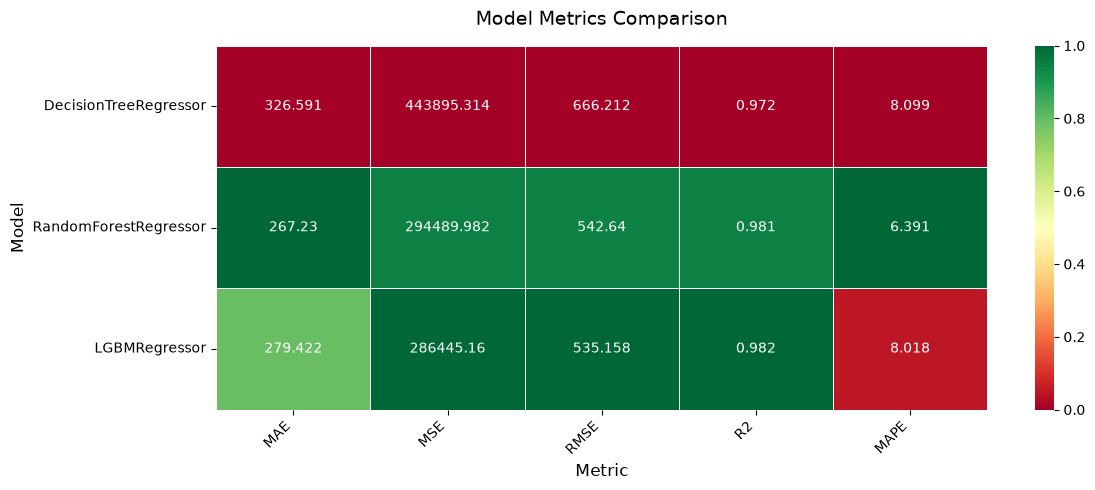

In [92]:
normalised_metrics_del = train_evaluate_models_cv(
    models=models,
    X=X_normalised_del,
    y=y,
    preprocessor=preprocessor_normalisation_del,
    cv=cv,
    seed=SEED
)

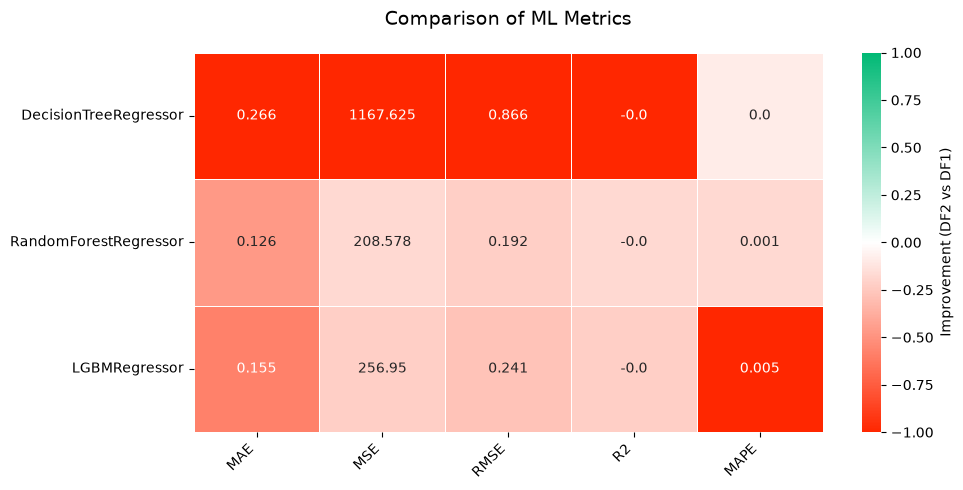

(<Figure size 1000x500 with 2 Axes>,
                             MAE          MSE      RMSE        R2      MAPE
 DecisionTreeRegressor  0.266350  1167.625347  0.866079 -0.000074  0.000407
 RandomForestRegressor  0.125863   208.577600  0.191917 -0.000013  0.000816
 LGBMRegressor          0.154631   256.949898  0.241165 -0.000016  0.004644)

In [93]:
compare_metrics_heatmap(initial_metrics, normalised_metrics_del)

Ухудшения метрик для всех моделей

### 2.7 Обработка выбросов

In [95]:
X_no_outliers = X.copy()

In [96]:
X_no_outliers = winsorize_outliers(X_no_outliers, 'carat', upper_bound=3)
X_no_outliers = winsorize_outliers(X_no_outliers, 'depth', lower_bound=55, upper_bound=67)
X_no_outliers = winsorize_outliers(X_no_outliers, 'table', lower_bound=50, upper_bound=67)
X_no_outliers = winsorize_outliers(X_no_outliers, 'x', lower_bound=4, upper_bound=9)
X_no_outliers = winsorize_outliers(X_no_outliers, 'y', lower_bound=4, upper_bound=9)
X_no_outliers = winsorize_outliers(X_no_outliers, 'z', lower_bound=2, upper_bound=6)

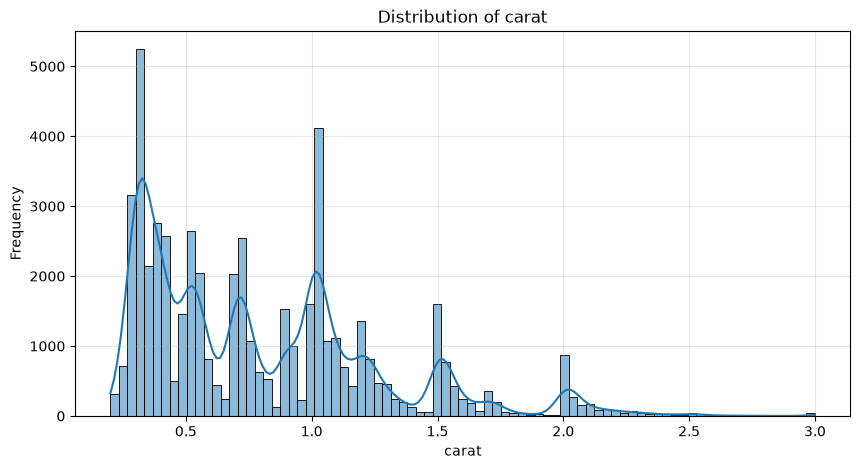

In [98]:
plot_hist_numeric(X_no_outliers, 'carat')

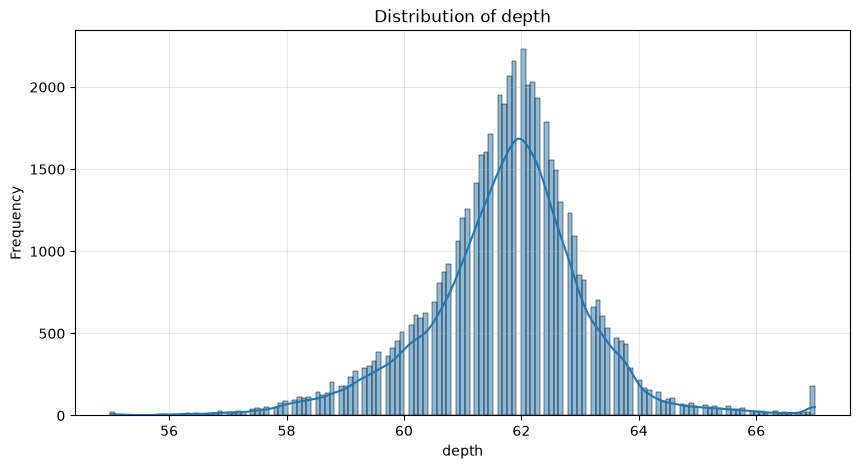

In [99]:
plot_hist_numeric(X_no_outliers, 'depth')

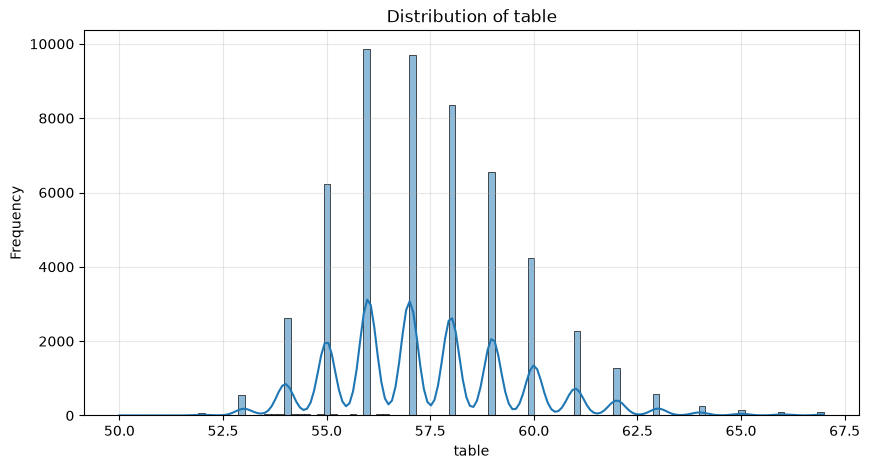

In [100]:
plot_hist_numeric(X_no_outliers, 'table')

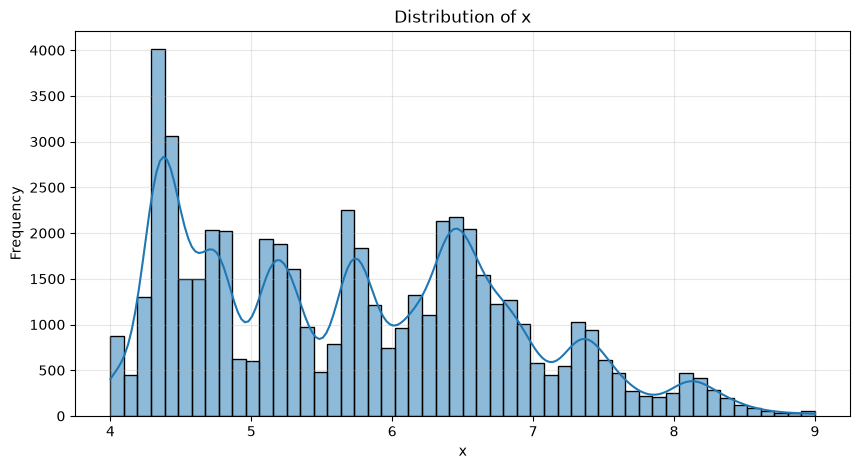

In [101]:
plot_hist_numeric(X_no_outliers, 'x')

c:\Users\meris\Desktop\Поиск работы\Обучение\Задания\regression-task\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\meris\Desktop\Поиск работы\Обучение\Задания\regression-task\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\meris\Desktop\Поиск работы\Обучение\Задания\regression-task\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000227 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1225
[LightGBM] [Info] Number of data points in the train set: 43020, number of used features: 9
[LightGBM] [Info] Start training from score 3931.021548
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000257 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1237
[LightGBM] [Info] Number of data points in the train set: 43020, number of used features: 9
[LightGBM] [Info] Start training from score 3931.795467
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000245 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not e

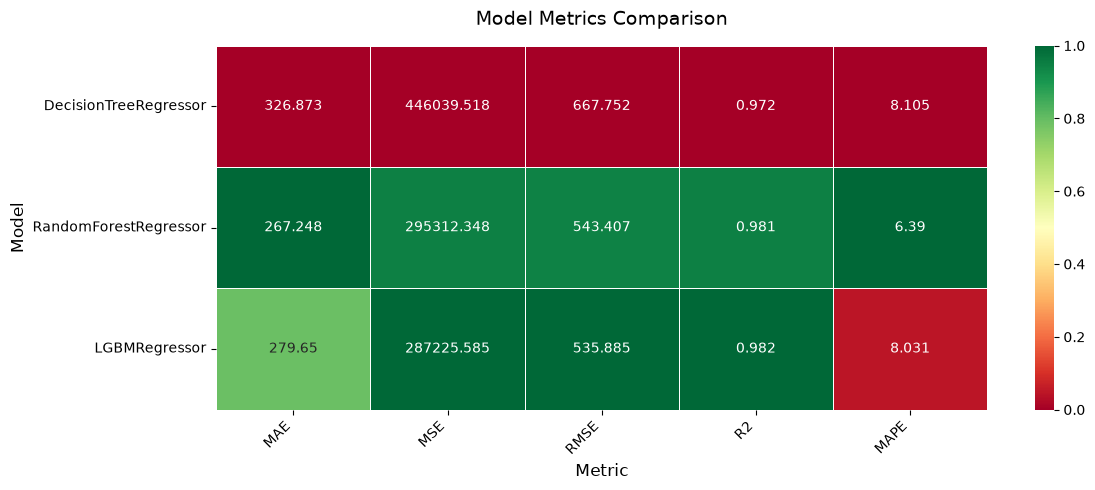

In [102]:
no_outliers_metrics = train_evaluate_models_cv(
    models=models,
    X=X_no_outliers,
    y=y,
    preprocessor=preprocessor,
    cv=cv,
    seed=SEED
)

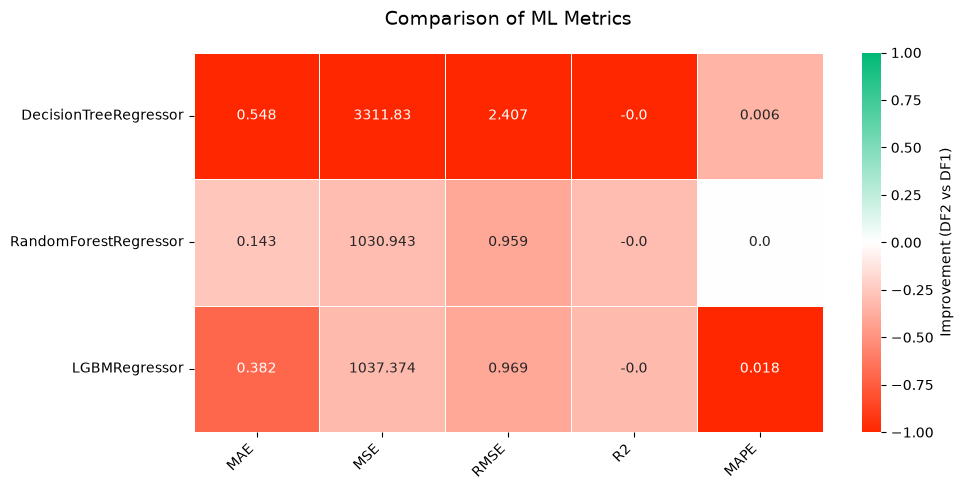

(<Figure size 1000x500 with 2 Axes>,
                             MAE          MSE      RMSE        R2      MAPE
 DecisionTreeRegressor  0.547778  3311.830252  2.406814 -0.000209  0.006227
 RandomForestRegressor  0.142940  1030.943004  0.959266 -0.000065  0.000071
 LGBMRegressor          0.382479  1037.374048  0.968544 -0.000065  0.017933)

In [103]:
compare_metrics_heatmap(initial_metrics, no_outliers_metrics)

Ухудшения метрик для всех моделей

### 2.9 carat_per_volume

c:\Users\meris\Desktop\Поиск работы\Обучение\Задания\regression-task\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\meris\Desktop\Поиск работы\Обучение\Задания\regression-task\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\meris\Desktop\Поиск работы\Обучение\Задания\regression-task\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000930 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1786
[LightGBM] [Info] Number of data points in the train set: 43020, number of used features: 11
[LightGBM] [Info] Start training from score 3931.021548
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000291 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1785
[LightGBM] [Info] Number of data points in the train set: 43020, number of used features: 11
[LightGBM] [Info] Start training from score 3931.795467
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000290 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] To

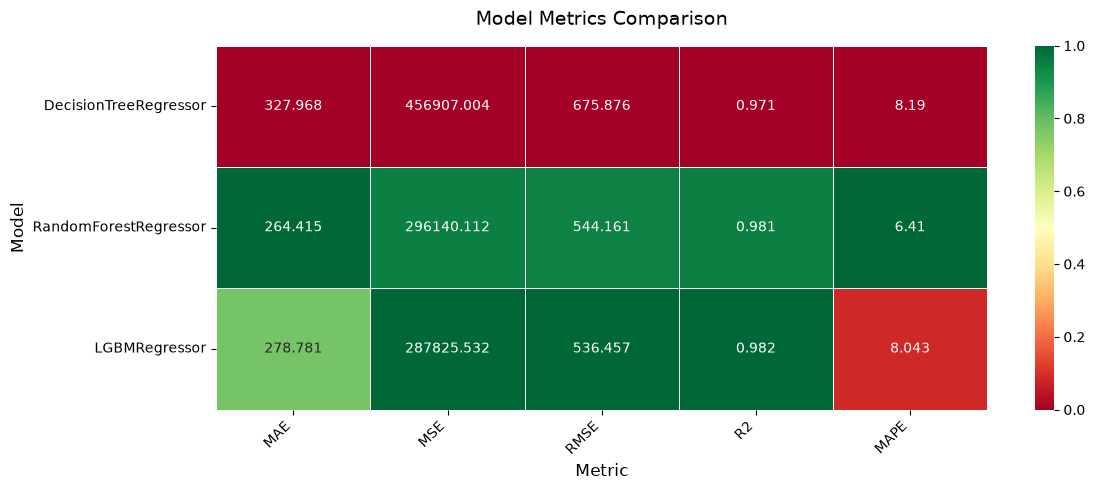

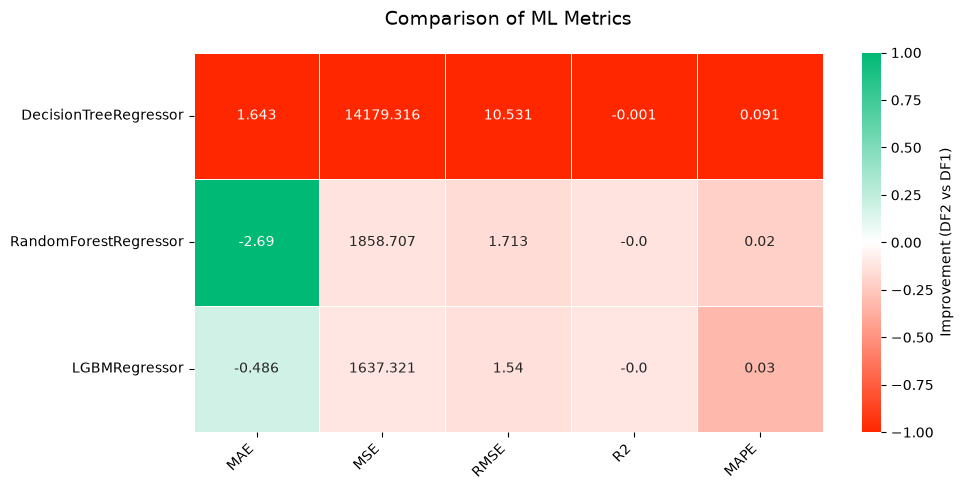

(<Figure size 1000x500 with 2 Axes>,
                             MAE           MSE       RMSE        R2      MAPE
 DecisionTreeRegressor  1.643239  14179.315922  10.530501 -0.000893  0.091358
 RandomForestRegressor -2.689512   1858.706860   1.712814 -0.000117  0.019571
 LGBMRegressor         -0.485833   1637.321233   1.539813 -0.000103  0.029738)

In [104]:
X_carat_per_volume = X.copy()
X_carat_per_volume['volume'] = X_carat_per_volume['x'] * X_carat_per_volume['y'] * X_carat_per_volume['z']
X_carat_per_volume['carat_per_volume'] = X_carat_per_volume['carat'] / (X_carat_per_volume['volume'] + 1e-6)
carat_per_volume_metrics = train_evaluate_models_cv(
    models=models,
    X=X_carat_per_volume,
    y=y,
    preprocessor=preprocessor,
    cv=cv,
    seed=SEED
)
compare_metrics_heatmap(initial_metrics, carat_per_volume_metrics)

Метрики ухудшились

### 2.10 carat_squared

c:\Users\meris\Desktop\Поиск работы\Обучение\Задания\regression-task\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\meris\Desktop\Поиск работы\Обучение\Задания\regression-task\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\meris\Desktop\Поиск работы\Обучение\Задания\regression-task\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000272 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1513
[LightGBM] [Info] Number of data points in the train set: 43020, number of used features: 10
[LightGBM] [Info] Start training from score 3931.021548
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000853 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1511
[LightGBM] [Info] Number of data points in the train set: 43020, number of used features: 10
[LightGBM] [Info] Start training from score 3931.795467
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000272 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] To

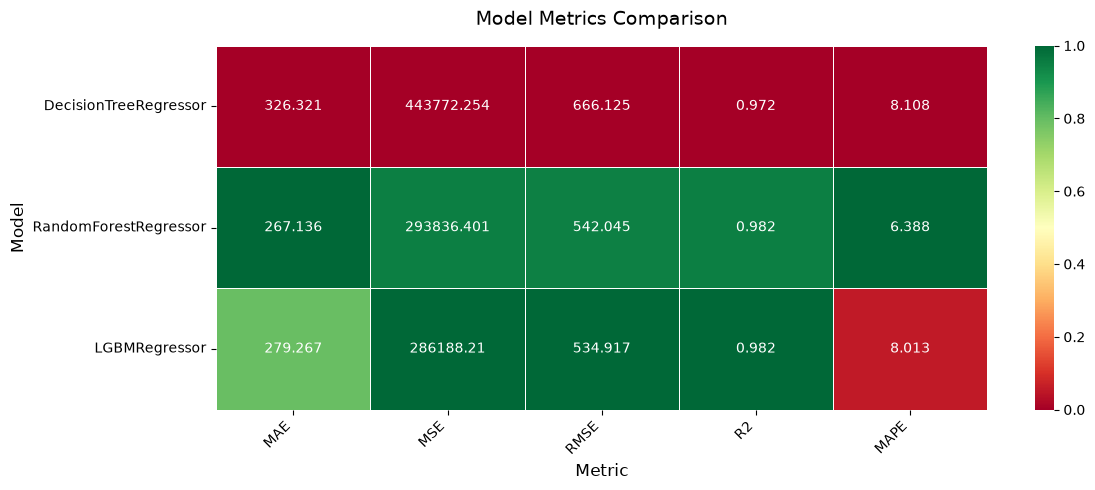

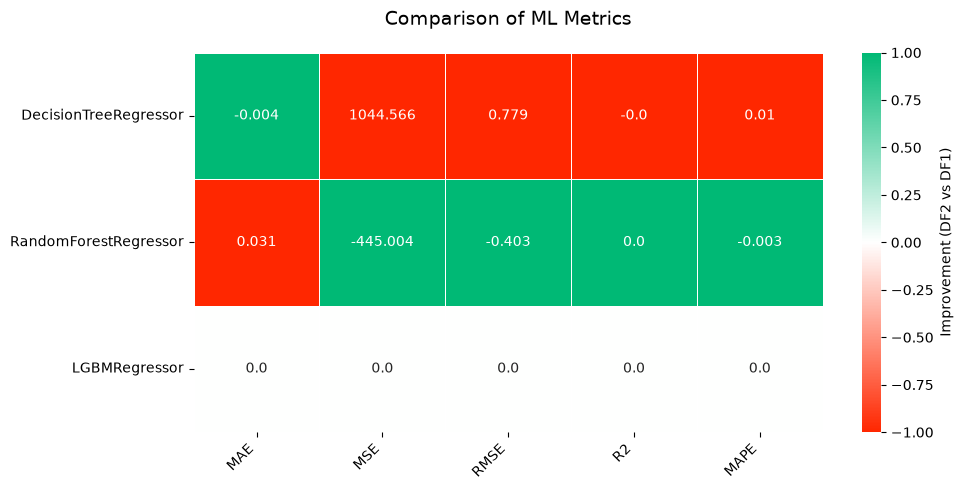

(<Figure size 1000x500 with 2 Axes>,
                             MAE          MSE      RMSE        R2      MAPE
 DecisionTreeRegressor -0.003670  1044.566160  0.779024 -0.000066  0.009579
 RandomForestRegressor  0.031095  -445.003668 -0.402969  0.000028 -0.002553
 LGBMRegressor          0.000000     0.000000  0.000000  0.000000  0.000000)

In [105]:
X_carat_squared = X.copy()
X_carat_squared['carat_squared'] = X_carat_squared['carat'] ** 2
carat_squared_metrics = train_evaluate_models_cv(
    models=models,
    X=X_carat_squared,
    y=y,
    preprocessor=preprocessor,
    cv=cv,
    seed=SEED
)
compare_metrics_heatmap(initial_metrics, carat_squared_metrics)

Незначительные улучшения для леса

### 2.11 table_depth_ratio

c:\Users\meris\Desktop\Поиск работы\Обучение\Задания\regression-task\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\meris\Desktop\Поиск работы\Обучение\Задания\regression-task\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\meris\Desktop\Поиск работы\Обучение\Задания\regression-task\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000253 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1531
[LightGBM] [Info] Number of data points in the train set: 43020, number of used features: 10
[LightGBM] [Info] Start training from score 3931.021548
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000436 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 43020, number of used features: 10
[LightGBM] [Info] Start training from score 3931.795467
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004510 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] To

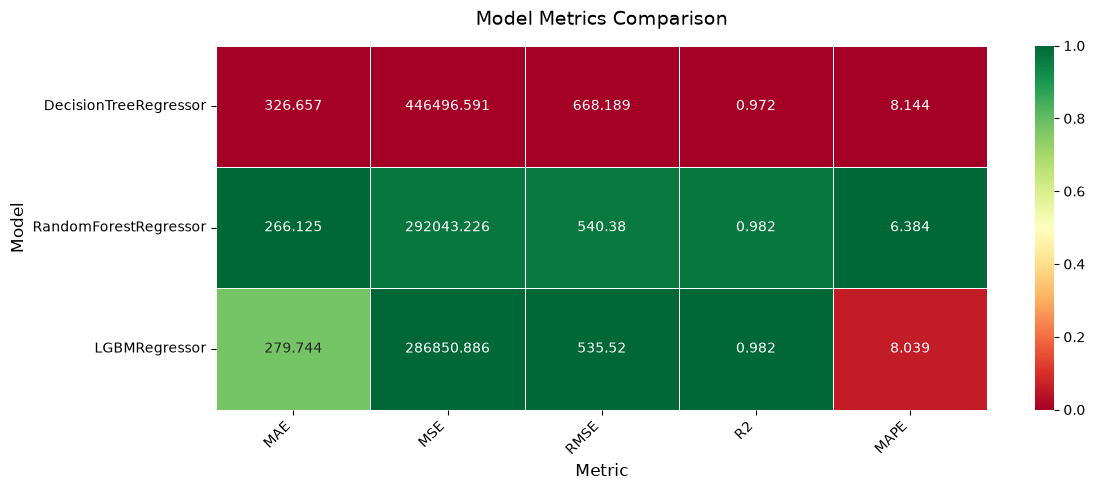

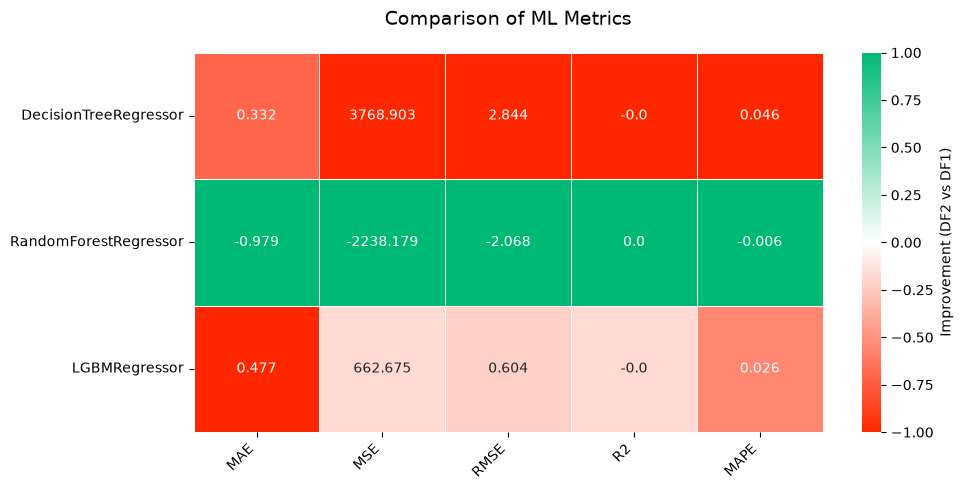

(<Figure size 1000x500 with 2 Axes>,
                             MAE          MSE      RMSE        R2      MAPE
 DecisionTreeRegressor  0.331894  3768.902948  2.843685 -0.000237  0.045585
 RandomForestRegressor -0.979338 -2238.179353 -2.067927  0.000141 -0.005870
 LGBMRegressor          0.476723   662.675410  0.603791 -0.000042  0.025591)

In [106]:
X_table_depth_ratio = X.copy()
X_table_depth_ratio['table_depth_ratio'] = X_table_depth_ratio['table'] / (X_table_depth_ratio['depth'] + 1e-6)
table_depth_ratio_metrics = train_evaluate_models_cv(
    models=models,
    X=X_table_depth_ratio,
    y=y,
    preprocessor=preprocessor,
    cv=cv,
    seed=SEED
)
compare_metrics_heatmap(initial_metrics, table_depth_ratio_metrics)

Небольшие улучшения для леса, небольшие ухудшения для бустинга

### 2.12 color_clarity

c:\Users\meris\Desktop\Поиск работы\Обучение\Задания\regression-task\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\meris\Desktop\Поиск работы\Обучение\Задания\regression-task\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\meris\Desktop\Поиск работы\Обучение\Задания\regression-task\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000269 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1388
[LightGBM] [Info] Number of data points in the train set: 43020, number of used features: 65
[LightGBM] [Info] Start training from score 3931.021548
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000272 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1387
[LightGBM] [Info] Number of data points in the train set: 43020, number of used features: 65
[LightGBM] [Info] Start training from score 3931.795467
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001036 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] To

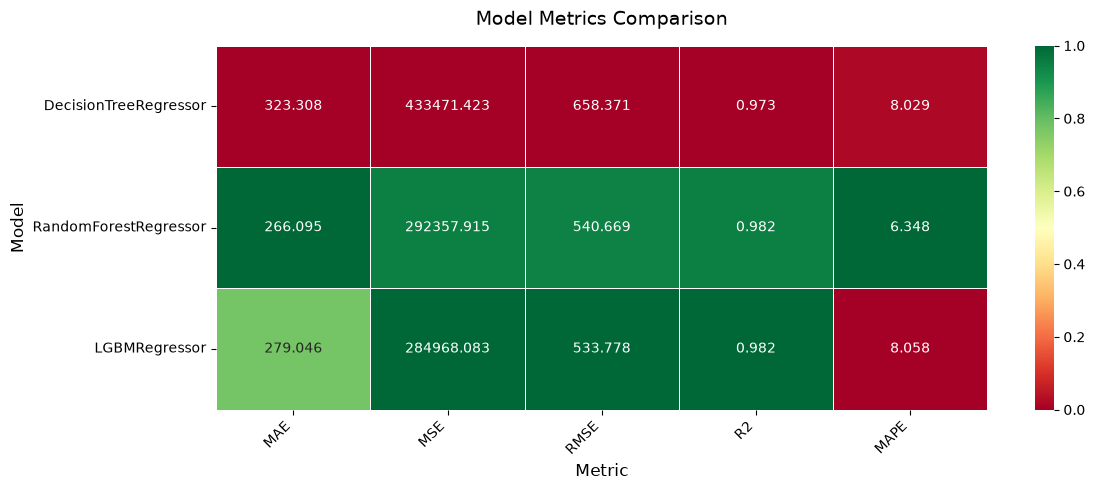

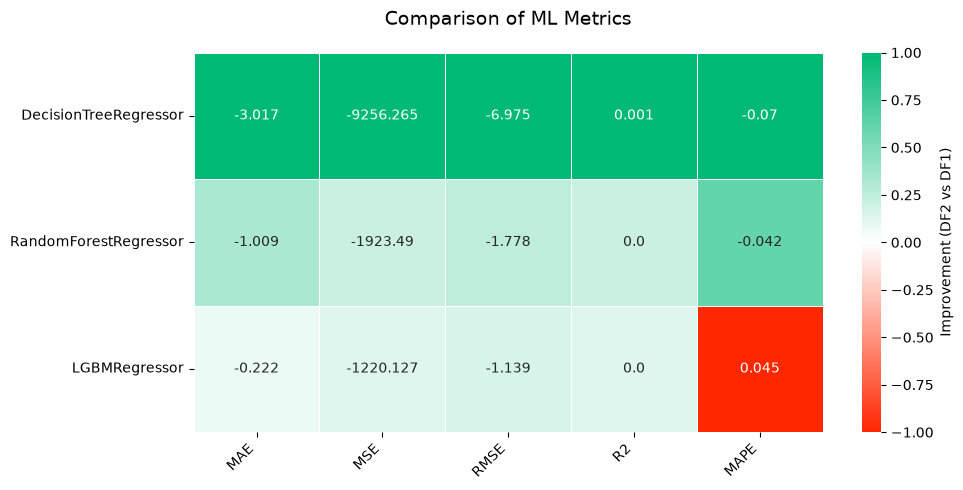

(<Figure size 1000x500 with 2 Axes>,
                             MAE          MSE      RMSE        R2      MAPE
 DecisionTreeRegressor -3.017074 -9256.265340 -6.974665  0.000583 -0.069815
 RandomForestRegressor -1.009112 -1923.490030 -1.778493  0.000121 -0.042259
 LGBMRegressor         -0.221663 -1220.127083 -1.138741  0.000077  0.044813)

In [110]:
X_color_clarity = X.copy()
X_color_clarity['color_clarity'] = X_color_clarity['color'].astype(str) + '_' + X_color_clarity['clarity'].astype(str)

preprocessor_color_clarity = Pipeline([    
    ("transformations", ColumnTransformer(
        [
            ("ordinal_encoder", OrdinalEncoder(categories=category_orders), categorical_cols),
            ("onehot_encoder", OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['color_clarity'])
        ],
        remainder="passthrough",
        verbose_feature_names_out=False
    ))
])

color_clarity_metrics = train_evaluate_models_cv(
    models=models,
    X=X_color_clarity,
    y=y,
    preprocessor=preprocessor_color_clarity,
    cv=cv,
    seed=SEED
)
compare_metrics_heatmap(initial_metrics, color_clarity_metrics)

Улучшения по большинству метрик для всех моделей

### 2.13 cut_clarity

c:\Users\meris\Desktop\Поиск работы\Обучение\Задания\regression-task\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\meris\Desktop\Поиск работы\Обучение\Задания\regression-task\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\meris\Desktop\Поиск работы\Обучение\Задания\regression-task\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000266 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1352
[LightGBM] [Info] Number of data points in the train set: 43020, number of used features: 47
[LightGBM] [Info] Start training from score 3931.021548
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000280 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1351
[LightGBM] [Info] Number of data points in the train set: 43020, number of used features: 47
[LightGBM] [Info] Start training from score 3931.795467
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000843 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] To

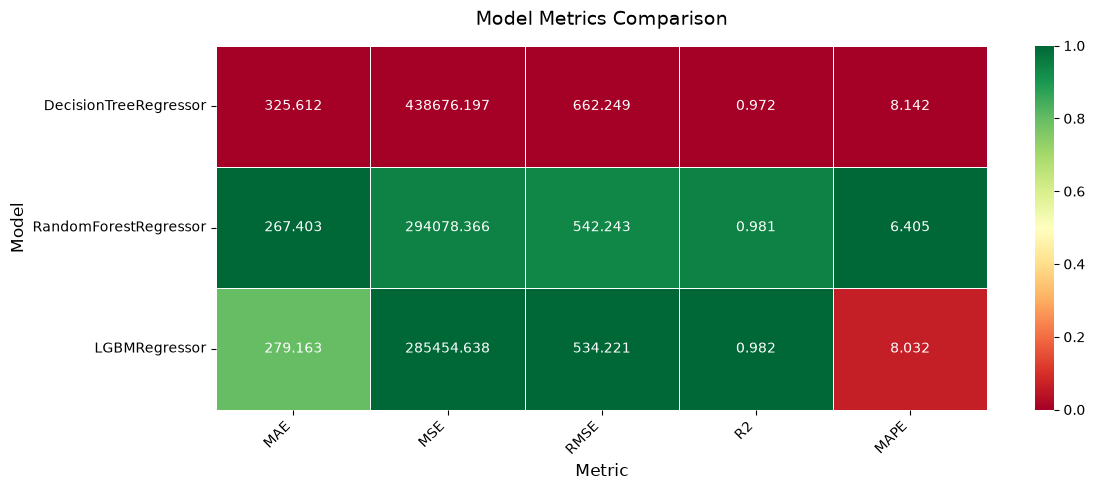

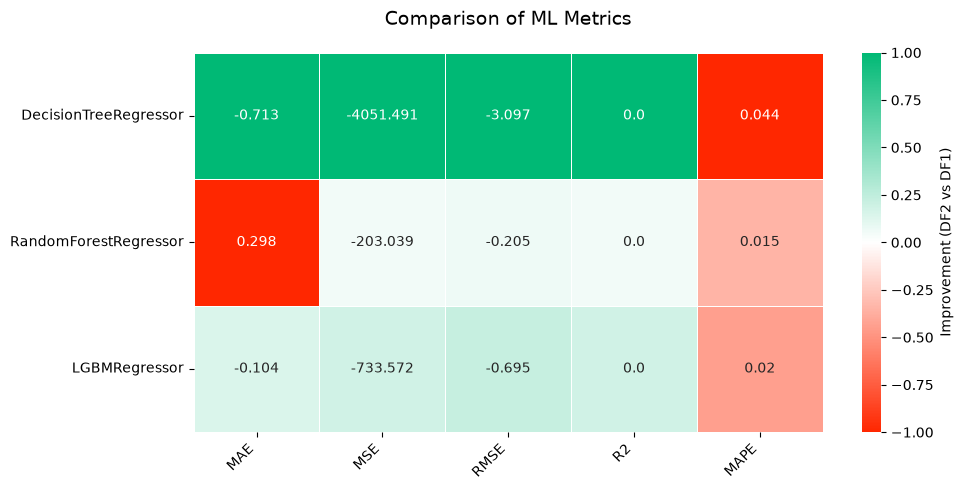

(<Figure size 1000x500 with 2 Axes>,
                             MAE          MSE      RMSE        R2      MAPE
 DecisionTreeRegressor -0.712601 -4051.490821 -3.096900  0.000255  0.043843
 RandomForestRegressor  0.297990  -203.039135 -0.205015  0.000013  0.015291
 LGBMRegressor         -0.103870  -733.572219 -0.695329  0.000046  0.019520)

In [111]:
X_cut_clarity = X.copy()
X_cut_clarity['cut_clarity'] = X_cut_clarity['cut'].astype(str) + '_' + X_cut_clarity['clarity'].astype(str)

preprocessor_cut_clarity = Pipeline([    
    ("transformations", ColumnTransformer(
        [
            ("ordinal_encoder", OrdinalEncoder(categories=category_orders), categorical_cols),
            ("onehot_encoder", OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['cut_clarity'])
        ],
        remainder="passthrough",
        verbose_feature_names_out=False
    ))
])

cut_clarity_metrics = train_evaluate_models_cv(
    models=models,
    X=X_cut_clarity,
    y=y,
    preprocessor=preprocessor_cut_clarity,
    cv=cv,
    seed=SEED
)
compare_metrics_heatmap(initial_metrics, cut_clarity_metrics)

Небольшие улучшения метрик

### 2.13 log_price

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000267 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1273
[LightGBM] [Info] Number of data points in the train set: 43020, number of used features: 9
[LightGBM] [Info] Start training from score 7.785974
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000256 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1276
[LightGBM] [Info] Number of data points in the train set: 43020, number of used features: 9
[LightGBM] [Info] Start training from score 7.787974
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000273 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough,

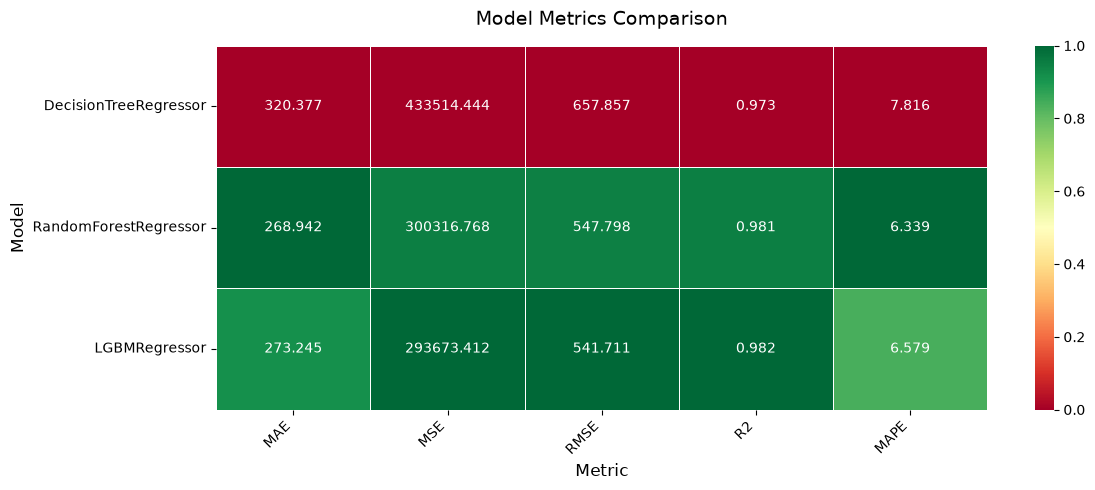

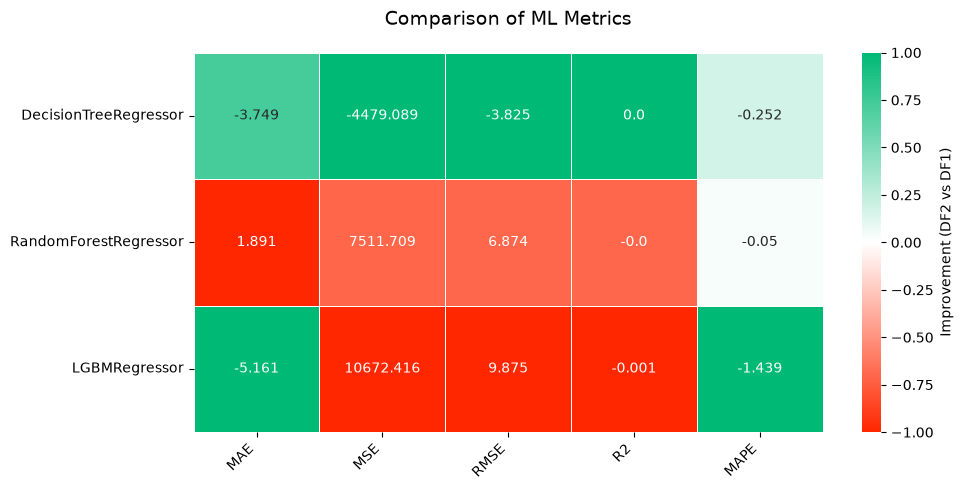

(<Figure size 1000x500 with 2 Axes>,
                             MAE           MSE      RMSE        R2      MAPE
 DecisionTreeRegressor -3.749245  -4479.089390 -3.825118  0.000285 -0.251800
 RandomForestRegressor  1.890702   7511.709065  6.873954 -0.000473 -0.050476
 LGBMRegressor         -5.160929  10672.415765  9.874541 -0.000675 -1.438522)

In [127]:
log_price_metrics = train_evaluate_models_cv_log(
    models=models,
    X=X,
    y=y,
    preprocessor=preprocessor,
    cv=5,
    seed=SEED
)

plot_metrics_heatmap(log_price_metrics)
compare_metrics_heatmap(initial_metrics, log_price_metrics)

Логарифмирование цены не дало стабильного улучшения

### 2.21 Итоговый результат

Из всех преобразований самый значительный результат дал `xy_ratio`

In [129]:
X_final = X.copy()

In [130]:
X_final['xy_ratio'] = X_final['x'] / (X_final['y'] + 1e-6)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000274 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1528
[LightGBM] [Info] Number of data points in the train set: 43020, number of used features: 10
[LightGBM] [Info] Start training from score 3930.301790
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000262 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1531
[LightGBM] [Info] Number of data points in the train set: 43020, number of used features: 10
[LightGBM] [Info] Start training from score 3937.058415
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000268 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not

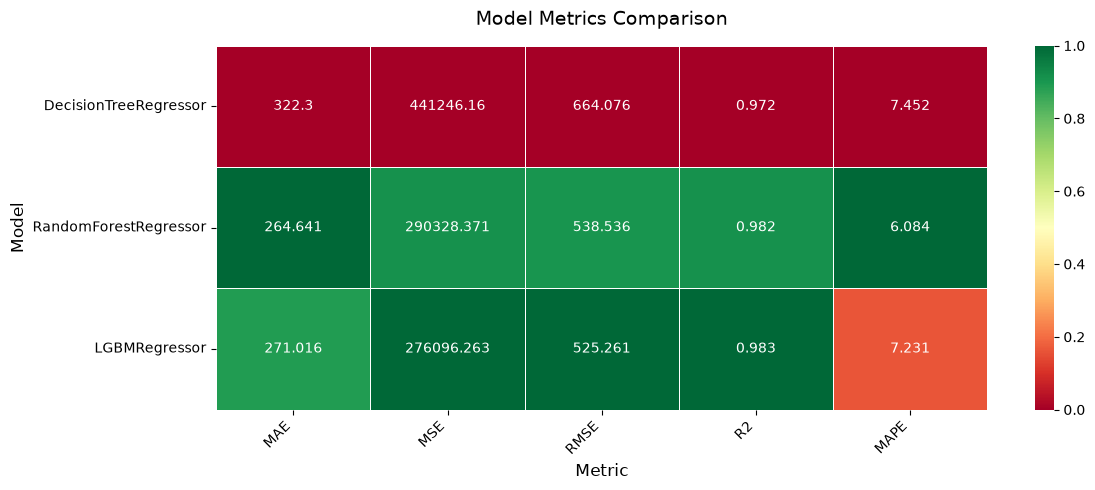

In [132]:
final_metrics = train_evaluate_models_cv(
    models=models,
    X=X_final,
    y=y,
    preprocessor=preprocessor,
    cv=cv,
    seed=SEED
)

На данный момент есть 2 фаворита: случайный лес и бустинг. 

В дальнейшем хочется сконцентрироваться на подборе гиперпараметров для бустинга, т.к. у него лучший R2 и RMSE - модель лучше объясняет дисперсию и меньше ошибается на больших значениях цены

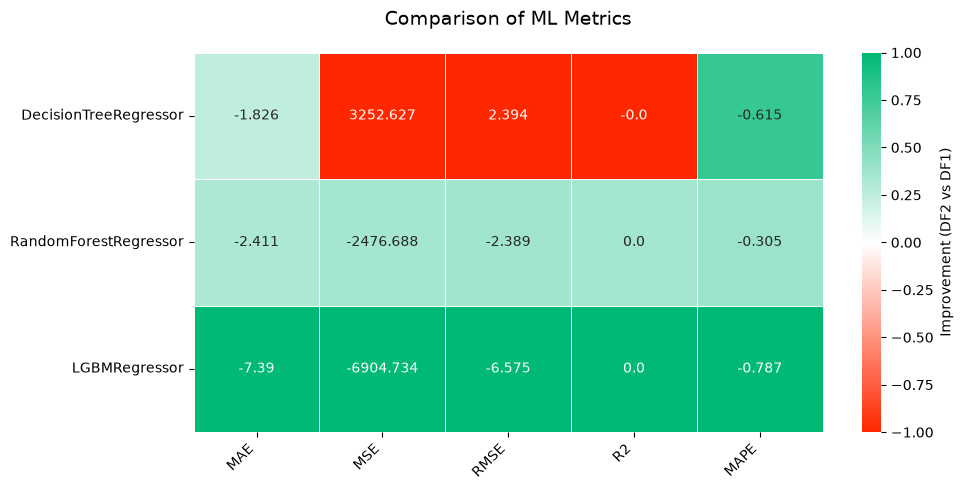

(<Figure size 1000x500 with 2 Axes>,
                             MAE          MSE      RMSE        R2      MAPE
 DecisionTreeRegressor -1.826482  3252.627056  2.393600 -0.000209 -0.615383
 RandomForestRegressor -2.410946 -2476.687824 -2.388609  0.000156 -0.305032
 LGBMRegressor         -7.389597 -6904.733612 -6.575210  0.000435 -0.787036)

In [133]:
compare_metrics_heatmap(initial_metrics, final_metrics)

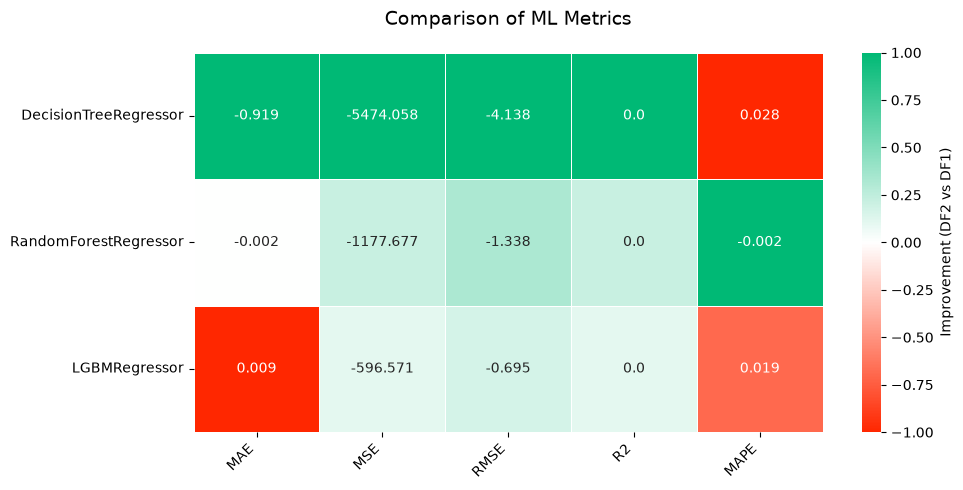

(<Figure size 1000x500 with 2 Axes>,
                             MAE          MSE      RMSE        R2      MAPE
 DecisionTreeRegressor -0.919296 -5474.058400 -4.138473  0.000335  0.027604
 RandomForestRegressor -0.002387 -1177.676824 -1.338175  0.000073 -0.002037
 LGBMRegressor          0.009097  -596.571412 -0.694579  0.000035  0.019179)

In [135]:
compare_metrics_heatmap(xy_ratio_metrics, final_metrics)